In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("European_Bank.csv")

df.head(10)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_26224\1249052169.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\Dhruv\Bank prediction model\Data\European_Bank.csv")


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,2025,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,2025,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,2025,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.drop(
    ['CustomerId','Surname'],
    axis=1,
    inplace=True
)

In [8]:
df['BalanceSalaryRatio'] = (
    df['Balance'] /
    (df['EstimatedSalary'] + 1)
)

In [9]:
df['AgeTenure'] = (
    df['Age'] *
    df['Tenure']
)

In [10]:
df['EngagementProduct'] = (
    df['NumOfProducts'] *
    df['IsActiveMember']
)

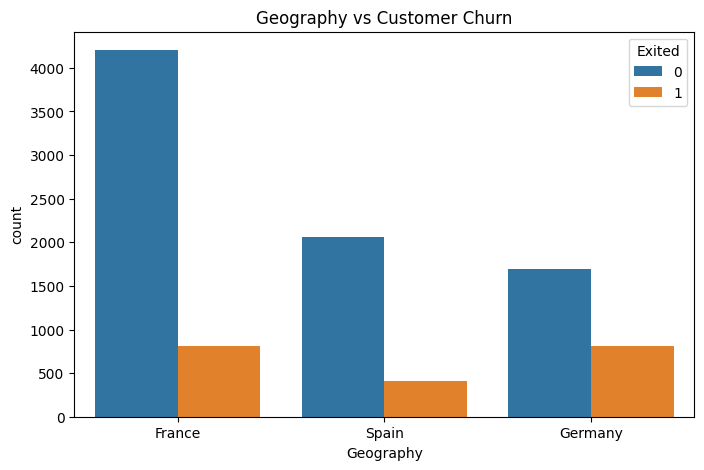

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title('Geography vs Customer Churn')

plt.show()

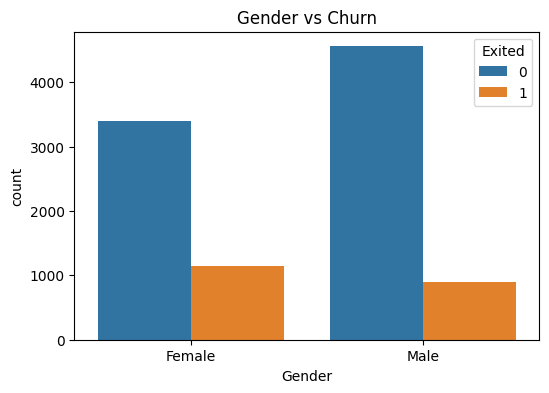

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title('Gender vs Churn')

plt.show()

In [13]:
df = pd.get_dummies(
    df,
    columns=['Geography','Gender'],
    drop_first=True
)

In [14]:
X = df.drop('Exited', axis=1)

y = df['Exited']

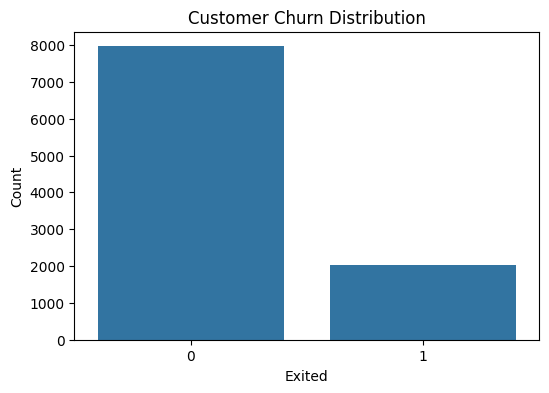

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Exited',
    data=df
)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited')
plt.ylabel('Count')

plt.show()

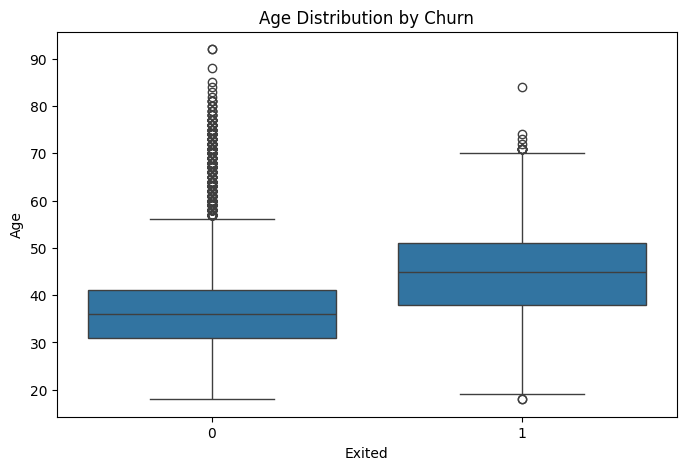

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Age',
    data=df
)

plt.title('Age Distribution by Churn')

plt.show()

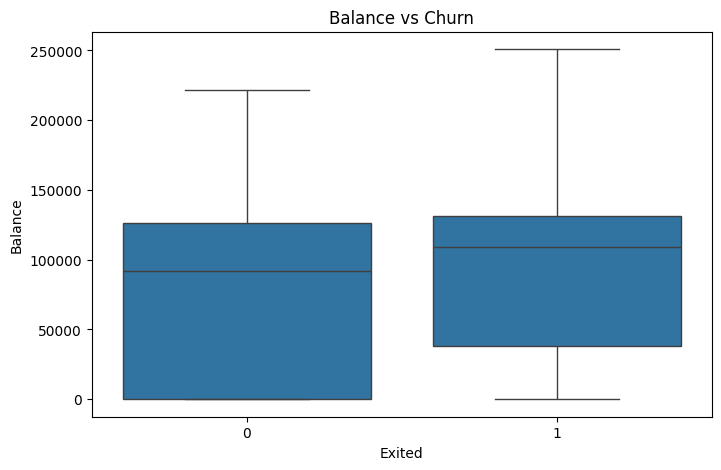

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.title('Balance vs Churn')

plt.show()

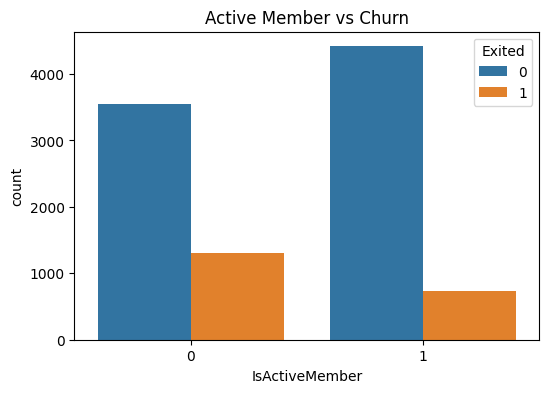

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=df
)

plt.title('Active Member vs Churn')

plt.show()

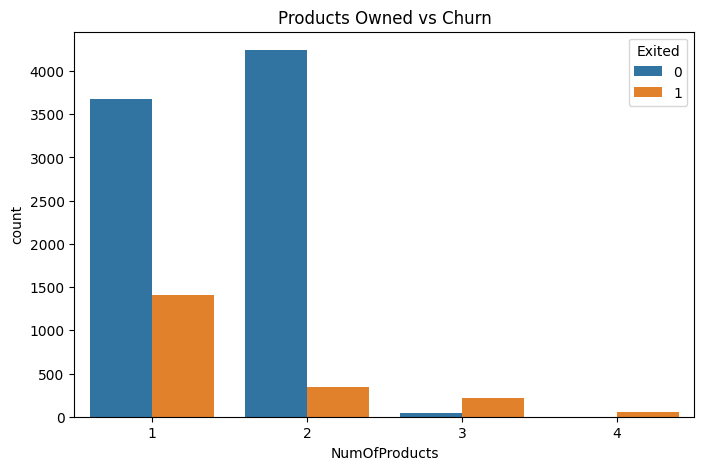

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='NumOfProducts',
    hue='Exited',
    data=df
)

plt.title('Products Owned vs Churn')

plt.show()

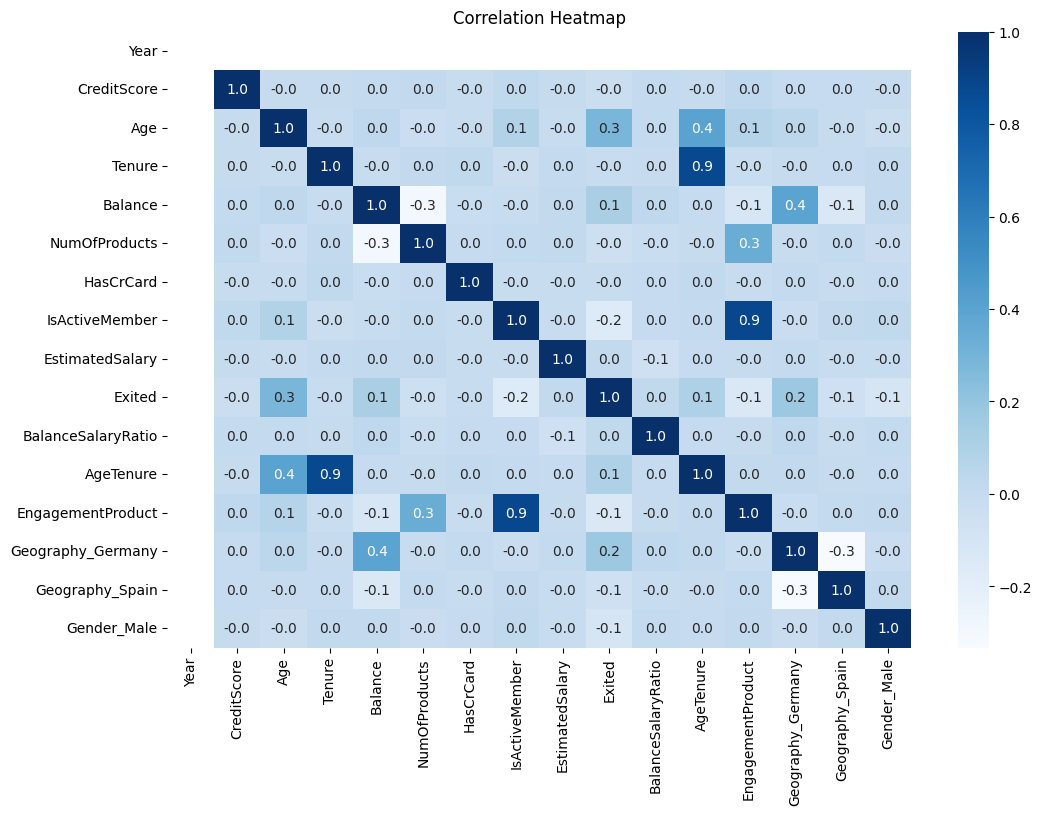

In [20]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    fmt='.1f'
)

plt.title('Correlation Heatmap')

plt.show()

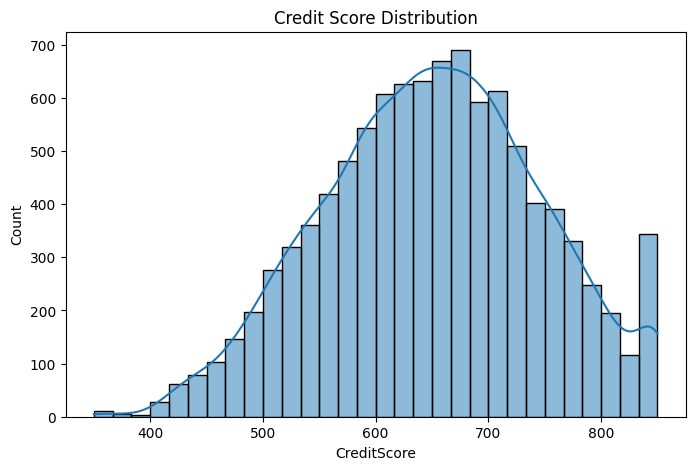

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['CreditScore'],
    bins=30,
    kde=True
)

plt.title('Credit Score Distribution')

plt.show()

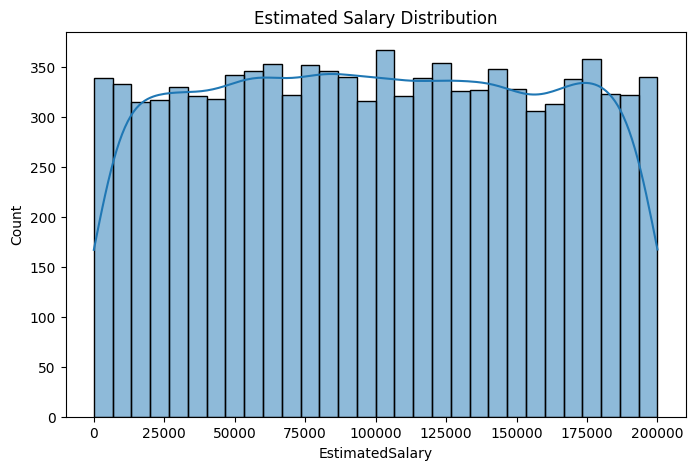

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['EstimatedSalary'],
    bins=30,
    kde=True
)

plt.title('Estimated Salary Distribution')

plt.show()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [25]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
lr_pred = lr.predict(
    X_test_scaled
)

lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

In [27]:
print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Precision:",
    precision_score(y_test, lr_pred)
)

print(
    "Recall:",
    recall_score(y_test, lr_pred)
)

print(
    "F1:",
    f1_score(y_test, lr_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, lr_prob)
)

Accuracy: 0.806
Precision: 0.5703703703703704
Recall: 0.1891891891891892
F1: 0.28413284132841327
ROC-AUC: 0.7738231297553332


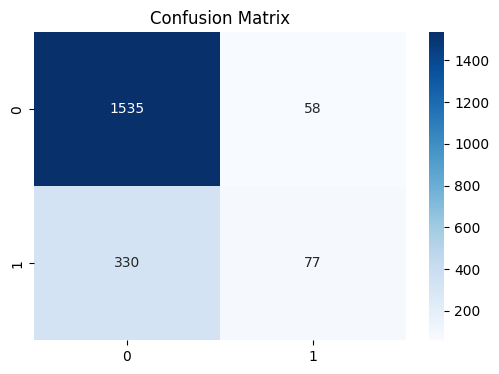

In [28]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

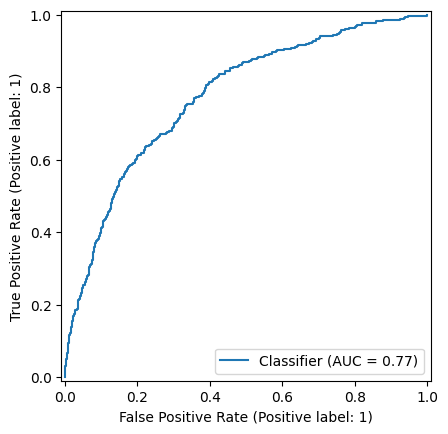

In [29]:
RocCurveDisplay.from_predictions(
    y_test,
    lr_prob
)

plt.show()

In [30]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
rf_pred = rf.predict(
    X_test
)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [32]:
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Precision:",
    precision_score(y_test, rf_pred)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred)
)

print(
    "F1:",
    f1_score(y_test, rf_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

Accuracy: 0.865
Precision: 0.7866108786610879
Recall: 0.4619164619164619
F1: 0.5820433436532507
ROC-AUC: 0.8549836431192365


In [34]:
import joblib

In [35]:
joblib.dump(rf, "rf_model.pkl")

['rf_model.pkl']

In [36]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [37]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [39]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
2,Age,0.200579
1,CreditScore,0.108670
8,EstimatedSalary,0.107712
5,NumOfProducts,0.102492
10,AgeTenure,0.101056
4,Balance,0.098787
9,BalanceSalaryRatio,0.087463
3,Tenure,0.054184
11,EngagementProduct,0.042545
12,Geography_Germany,0.026491


In [47]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

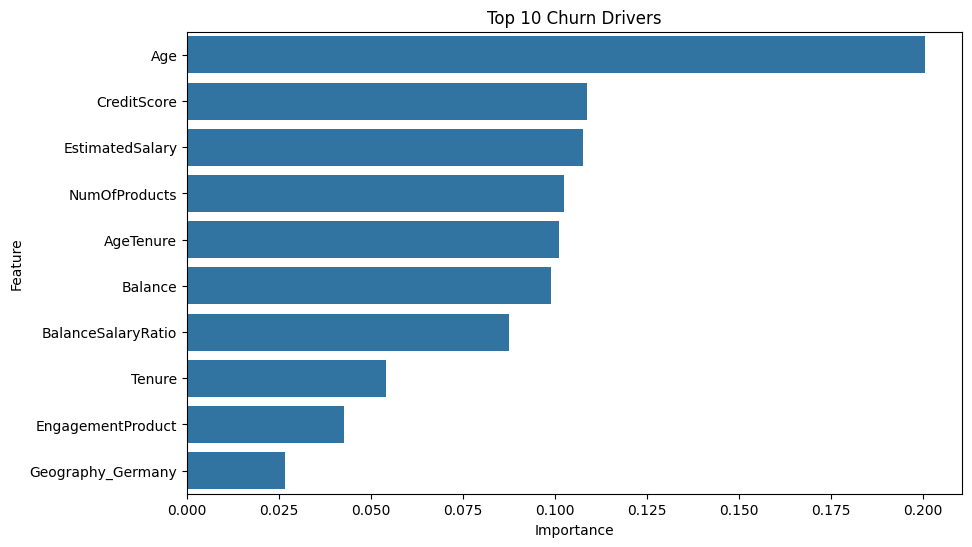

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(10),

    x='Importance',

    y='Feature'

)

plt.title(
    "Top 10 Churn Drivers"
)

plt.show()

In [41]:
df['Churn_Probability'] = rf.predict_proba(
    X
)[:,1]

In [42]:
df['Risk_Score'] = (
    df['Churn_Probability'] * 100
).round(2)

In [43]:
def risk_category(score):

    if score >= 70:
        return "High Risk"

    elif score >= 40:
        return "Medium Risk"

    else:
        return "Low Risk"


df['Risk_Category'] = df[
    'Risk_Score'
].apply(risk_category)

In [44]:
df[
    [
        'Risk_Score',
        'Risk_Category'
    ]
].head()

,Risk_Score,Risk_Category
0,70.5,High Risk
1,9.5,Low Risk
2,97.0,High Risk
3,2.5,Low Risk
4,2.5,Low Risk


In [45]:
high_risk = df[
    df['Risk_Category']
    ==
    'High Risk'
]

high_risk.head()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,AgeTenure,EngagementProduct,Geography_Germany,Geography_Spain,Gender_Male,Churn_Probability,Risk_Score,Risk_Category
0,2025,619,42,2,0.00,1,1,1,101348.88,1,0.000000,84,1,False,False,False,0.705,70.5,High Risk
2,2025,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,336,0,False,False,False,0.970,97.0,High Risk
7,2025,376,29,4,115046.74,4,1,0,119346.88,1,0.963961,116,0,True,False,False,0.955,95.5,High Risk
16,2025,653,58,1,132602.88,1,1,0,5097.67,1,26.007347,58,0,True,False,True,0.970,97.0,High Risk
35,2025,475,45,0,134264.04,1,1,0,27822.99,1,4.825478,0,0,False,False,False,0.845,84.5,High Risk


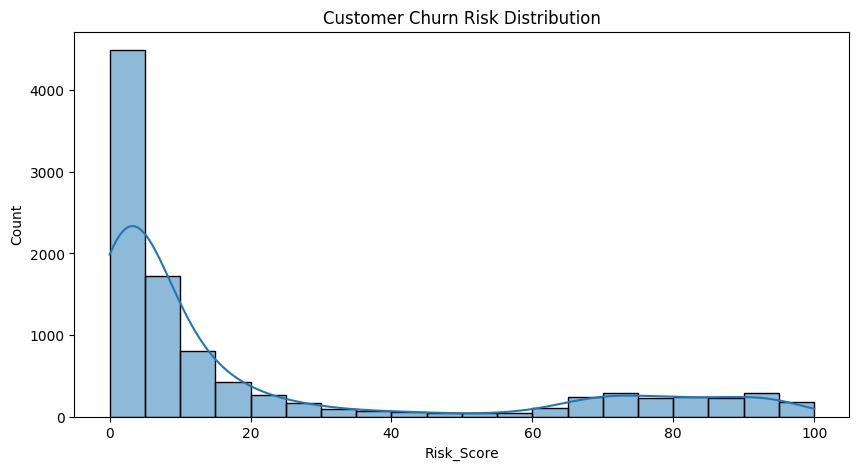

In [46]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Risk_Score'],
    bins=20,
    kde=True
)

plt.title(
    "Customer Churn Risk Distribution"
)

plt.show()